# ⚽ Segmentación de jugadores de fútbol (5 grandes ligas europeas, 2023-24)
## Clustering de perfiles **por posición** — Protocolo CRISP-DM

Construye **cuatro modelos de clustering independientes**, uno por posición: porteros (GK), defensas (DF), mediocampistas (MF) y delanteros (FW).

| | |
|---|---|
| **Datos** | La Liga, Ligue 1, Premier League, Serie A y Bundesliga · temporada 2023-24 |
| **Fuente** | FBref vía `soccerdata`, tabla combinada de las 5 grandes ligas |
| **Tablas** | `standard`, `shooting`, `playing_time`, `misc`, `keeper` |
| **Resultado** | **15 perfiles**: 3 en GK, 3 en DF, 4 en MF, 5 en FW |

**Estructura**

| Sección | Contenido | Fase CRISP-DM |
|---|---|---|
| 1 | Comprensión del negocio | 1 |
| 2 | Comprensión de los datos | 2 |
| 3 | Preparación común: filtros, 4 datasets y funciones reutilizables | 3 |
| 4 | Modelo de **porteros (GK)** | 3 · 4 · 5 |
| 5 | Modelo de **defensas (DF)** | 3 · 4 · 5 |
| 6 | Modelo de **mediocampistas (MF)** | 3 · 4 · 5 |
| 7 | Modelo de **delanteros (FW)** | 3 · 4 · 5 |
| 8 | Evaluación comparativa y despliegue | 5 · 6 |

- Fases **1 y 2**: comunes a las cuatro posiciones (mismo origen de datos).
- Desde la **fase 3**: cada posición sigue su propio camino — variables, escalado, `k` y modelo propios.

---
## 1. Comprensión del negocio (*Business Understanding*)

### Objetivo

Identificar de forma no supervisada **arquetipos de jugadores dentro de cada posición**, a partir de métricas de rendimiento por 90 minutos.

### Por qué un modelo por posición y no uno global

- Un clustering único gasta sus primeros cortes en **redescubrir la posición** (separa delanteros de defensas), algo que ya dice la columna `pos`.
- Segmentando **dentro** de cada línea, el modelo debe distinguir *roles*: central agresivo vs. central de salida, extremo centrador vs. nueve de área, pivote de corte vs. interior llegador.
- Cada línea se juzga con **métricas distintas**: el % de parada solo aplica a un portero; los centros solo describen un rol en bandas.

### Qué miden los datos

| Bloque | Métricas |
|---|---|
| Producción ofensiva | goles, asistencias, goles sin penalti (por 90) |
| Volumen de remate | tiros y tiros a puerta por 90 |
| Juego por bandas | centros por 90 |
| Aporte defensivo | intercepciones, entradas ganadas |
| Disciplina y roce | faltas cometidas y recibidas, tarjetas, fueras de juego |
| Portería (`keeper`) | goles encajados, paradas, % de parada, tiros a puerta en contra, porterías a cero |

> ⚠️ **No hay** xG, pases progresivos ni duelos aéreos. Para porteros tampoco PSxG, salidas del área ni juego con los pies. Requeriría añadir `passing`, `possession`, `defense` o `keeper_adv` en la recolección para unos datos más completos.

### Usos del resultado

- **Scouting**: encontrar perfiles similares a uno dado *dentro de su posición* (sustitutos, objetivos de fichaje).
- **Comparación** entre jugadores que comparten posición pero cumplen roles distintos.
- Detectar **atípicos** que no encajan en ningún perfil dominante de su línea.

### Criterios de éxito

- **Interpretables**: cada cluster admite un nombre futbolístico con sentido.
- **Más finos que la posición**: si dentro de los defensas no distinguen roles, el modelo no sirve.
- **Estables** ante cambios pequeños en los datos — *no medido en este notebook*, queda como trabajo futuro (sección 8).

### Decisiones metodológicas

- **Un clustering independiente por posición**, cada uno con sus variables, su escalado y su `k`.
- Los **porteros entran** con modelo propio basado en `keeper`; no se mezclan con jugadores de campo porque sus métricas no son comparables.
- Un **polivalente** (`"DF,MF"`, `"MF,FW"`...) se evalúa **en los dos datasets**: su perfil como defensa y como mediocampista son preguntas distintas.
- **Dos umbrales de minutos** (detalle en 3.1):
  - *Entrenamiento* — quién define los perfiles: **10 partidos completos** (15 en porteros).
  - *Inclusión* — quién recibe etiqueta: **5 partidos**, marcando su confianza.
  - Así los arquetipos salen de datos fiables sin dejar fuera al suplente ni al juvenil, que son el caso de uso natural del scouting.

---
## 2. Comprensión de los datos (*Data Understanding*)

### 2.1 Recolección

Descarga de FBref las tablas `standard`, `shooting`, `playing_time`, `misc` y `keeper`, las une y guarda un CSV local.

- **`keeper` habilita el modelo de porteros** (sección 4): goles encajados, paradas, % de parada, tiros a puerta en contra, porterías a cero.
- Los jugadores de campo tienen esas columnas vacías, y los porteros no tienen métricas de remate. Es esperado: **cada modelo usa solo las columnas de su posición**, así que los vacíos de una nunca llegan a otra.
- El CSV funciona como **caché**. Para volver a descargar: `recolectar_datos_permitidos(forzar_descarga=True)`.

In [1]:
import _bootstrap  # noqa: F401 — pone la raíz del proyecto en sys.path

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from config import parametros as P
from config import rutas as R
from src import datos, modelado, preparacion, visualizacion
from src.utils import mostrar

# La descarga vive en src/datos.py. Guarda el resultado en data/raw/ y en las siguientes
# ejecuciones lo lee de ahí, así que este notebook no vuelve a golpear a FBref.
print(f"Ligas:     {P.FBREF_LIGAS}")
print(f"Temporada: {P.FBREF_TEMPORADAS}")
print(f"Tablas:    {P.FBREF_TABLAS}")
print(f"Caché:     {R.CSV_CRUDO.relative_to(R.RAIZ)}")

Ligas:     ['Big 5 European Leagues Combined']
Temporada: ['2324']
Tablas:    ['standard', 'shooting', 'playing_time', 'misc', 'keeper']
Caché:     data\raw\datos_jugadores_permitidos.csv


In [2]:
df_raw = datos.recolectar_datos_permitidos()

print(f"\nDatos cargados: {df_raw.shape[0]} jugadores, {df_raw.shape[1]} columnas.")
df_raw.head()

📂 Cargando datos desde caché local: 'datos_jugadores_permitidos.csv'

Datos cargados: 3512 jugadores, 75 columnas.


,league,season,team,player,nation,pos,age,born,Playing Time_MP,Playing Time_Starts,...,Performance_W,Performance_D,Performance_L,Performance_CS,Performance_CS%,Penalty Kicks_PKatt,Penalty Kicks_PKA,Penalty Kicks_PKsv,Penalty Kicks_PKm,Penalty Kicks_Save%
0,ENG-Premier League,2324,Arsenal,Aaron Ramsdale,ENG,GK,25.0,1998.0,6.0,6.0,...,5.0,1.0,0.0,2.0,33.3,0.0,0.0,0.0,0.0,NaN
1,ENG-Premier League,2324,Arsenal,Ben White,ENG,DF,25.0,1997.0,37.0,35.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ENG-Premier League,2324,Arsenal,Bukayo Saka,ENG,FW,21.0,2001.0,35.0,35.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ENG-Premier League,2324,Arsenal,Cédric Soares,POR,"DF,MF",31.0,1991.0,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ENG-Premier League,2324,Arsenal,David Raya,ESP,GK,27.0,1995.0,32.0,32.0,...,23.0,4.0,5.0,14.0,43.8,3.0,2.0,1.0,0.0,33.3


### 2.2 Exploración inicial

Tamaño, tipos de dato, faltantes y descriptivos básicos — el paso estándar de *Data Understanding* antes de tocar nada.

In [3]:
print("Dimensiones:", df_raw.shape)
print("\nTipos de dato:")
print(df_raw.dtypes.value_counts())


Dimensiones: (3512, 75)

Tipos de dato:
float64    65
str         5
int64       5
Name: count, dtype: int64


In [4]:
faltantes = df_raw.isna().mean().sort_values(ascending=False) * 100
faltantes = faltantes[faltantes > 0]
print(f"Columnas con datos faltantes: {len(faltantes)} de {df_raw.shape[1]}")

# Columnas 100% vacías: FBref las trae en la cabecera pero sin ningún valor.
# No aportan nada al modelo y además rompen la imputación, así que se descartan en la fase 3.
cols_vacias = faltantes[faltantes == 100].index.tolist()
print(f"Columnas completamente vacías (se descartarán): {cols_vacias}")

faltantes.head(20)


Columnas con datos faltantes: 68 de 75
Columnas completamente vacías (se descartarán): ['Performance_PKwon', 'Performance_PKcon']


Performance_PKwon      100.000000
Performance_PKcon      100.000000
Penalty Kicks_Save%     96.298405
Performance_CS%         94.646925
Performance_Save%       94.305239
Penalty Kicks_PKatt     94.219818
Performance_CS          94.219818
Performance_D           94.219818
Performance_L           94.219818
Penalty Kicks_PKA       94.219818
Penalty Kicks_PKsv      94.219818
Penalty Kicks_PKm       94.219818
Performance_Saves       94.219818
Performance_SoTA        94.219818
Performance_GA          94.219818
Performance_W           94.219818
Performance_GA90        94.219818
Standard_G/SoT          42.995444
Standard_G/Sh           33.883827
Standard_SoT%           33.883827
dtype: float64

In [5]:
df_raw.describe(include='number').T.head(15)


,count,mean,std,min,25%,50%,75%,max
season,3512.0,2324.000000,0.000000,2324.0,2324.00,2324.0,2324.0,2324.0
age,2852.0,25.052595,4.592558,15.0,22.00,25.0,28.0,40.0
born,2852.0,1997.607644,4.598124,1982.0,1994.00,1998.0,2001.0,2008.0
Playing Time_MP,2852.0,18.969846,11.518387,1.0,8.00,20.0,29.0,38.0
Playing Time_Starts,2852.0,13.514727,11.251227,0.0,2.00,12.0,23.0,38.0
Playing Time_Min,2852.0,1213.301543,961.585849,1.0,296.75,1113.0,1987.0,3420.0
Playing Time_90s,2852.0,13.482363,10.685040,0.0,3.30,12.4,22.1,38.0
Performance_Gls,2852.0,1.720547,3.203617,0.0,0.00,0.0,2.0,36.0
Performance_Ast,2852.0,1.221950,1.965371,0.0,0.00,0.0,2.0,14.0
Performance_G+A,2852.0,2.942496,4.615810,0.0,0.00,1.0,4.0,44.0


---
## 3. Preparación de los datos (*Data Preparation*) — parte común

Solo lo que es **igual para las cuatro posiciones**, más las piezas que cada una reutilizará.

**1 · Filtro base**
- Se descartan las filas sin datos (plantilla que no llegó a jugar: FBref las trae con `pos` y minutos vacíos) y quienes no llegan a 450 minutos.
- Dentro de cada dataset se marca quién **entrena** el modelo y quién solo recibe etiqueta — dos umbrales distintos, justificados en 3.1.

**2 · Separación en 4 datasets**
- FBref reporta la posición como texto (`"MF"`, `"MF,FW"`, `"DF,MF"`...), así que se busca el código como **subcadena, no por igualdad**.
- Un polivalente entra en los **dos** datasets que le corresponden.
- La suma de los cuatro datasets supera al total de jugadores, y es correcto: cada aparición responde a una pregunta distinta.

**3 · Diccionario `FEATURES`**
- Lo que define el perfil de un portero no es lo que define el de un extremo, así que cada modelo recibe su propia lista de variables.

**4 · Funciones reutilizables** (fases 3, 4 y 5)

| Función | Qué hace |
|---|---|
| `preparar_features()` | totales a por-90 → imputación → escalado |
| `elegir_k()` | método del codo + coeficiente de silueta |
| `proyectar_pca()` | proyección a 3 componentes, en 3D y en sus tres planos |
| `ajustar_y_evaluar()` | K-Means final, silueta, PCA, perfil de cada cluster y representativos |

**5 · Evidencia de las tres decisiones** (3.1 a 3.3): por qué el umbral de minutos es distinto en cada posición, por qué el escalado es Yeo-Johnson y qué aporta cada variable. Cada bloque explica qué calcula su celda y termina en una figura.

A partir de la sección 4, **cada posición corre su propia fase 3, 4 y 5** con estas funciones.

In [6]:
# Los dos umbrales están en config/parametros.py, con el razonamiento de cada corte.
# Un solo sitio donde cambiarlos: este notebook, los cuatro modelos y el dashboard los
# leen de ahí, y antes estaban escritos por triplicado.
print(f"Inclusión (quién recibe etiqueta):  {P.MINUTOS_INCLUSION} min "
      f"= {P.MINUTOS_INCLUSION // P.PARTIDO} partidos, igual para las cuatro posiciones\n")
print("Entrenamiento (quién define los perfiles):")
for pos in P.POSICIONES:
    print(f"  {P.NOMBRE_POS[pos]:15s} {P.MINUTOS_ENTRENAMIENTO[pos]:5d} min "
          f"= {P.MINUTOS_ENTRENAMIENTO[pos] // P.PARTIDO:2d} partidos")
print()

# --- 1) Filtro base: relleno de la Bundesliga + filas sin posición ---
df_base = datos.cargar_base(df_raw)

# --- 2) Separación en 4 datasets ---
datasets = preparacion.construir_datasets(df_base)

# --- 3) Universo analizado, cobertura de scouting y polivalentes ---
analizados, polivalentes = preparacion.universo_analizado(df_base, datasets)

Inclusión (quién recibe etiqueta):  450 min = 5 partidos, igual para las cuatro posiciones

Entrenamiento (quién define los perfiles):
  Porteros         1350 min = 15 partidos
  Defensas          900 min = 10 partidos
  Mediocampistas    900 min = 10 partidos
  Delanteros        900 min = 10 partidos

Etiquetados como GER-Bundesliga: 18 equipos, 583 filas (Augsburg, Bayern Munich, Bochum, Darmstadt 98...)
Jugadores en el CSV:                    3512
  - sin posición / sin minutos jugados: 660
Jugadores con posición registrada:      2852



--- Los 4 datasets (inclusión: 450 min) ---
código       posición umbral_entren.  n_etiquetados  n_entrenan  n_conf_baja  % conf. baja
    GK       Porteros       15 part.            137         103           34          25.0
    DF       Defensas       10 part.            779         645          134          17.0
    MF Mediocampistas       10 part.           1097         887          210          19.0
    FW     Delanteros       10 part.            496         385          111          22.0

--- Reparto por liga (jugadores en al menos un modelo) ---
league
ITA-Serie A           426
ESP-La Liga           420
ENG-Premier League    404
FRA-Ligue 1           362
GER-Bundesliga        351

Jugadores de 21 años o menos con etiqueta: 321 de 1963 analizados

Suma de los 4 datasets: 2509 apariciones para 1963 jugadores distintos
Jugadores polivalentes: 546
pos
MF,FW    186
DF,MF    128
MF,DF    119
FW,MF    113


In [7]:
# Las cuatro listas de variables están en config/parametros.py, cada una con el
# comentario de qué capta y por qué quedaron fuera las demás candidatas.
print("Variables por modelo:\n")
for pos in P.POSICIONES:
    faltan = [c for c in P.FEATURES[pos] if c not in df_raw.columns]
    aviso = f"   ⚠️ NO ESTÁN EN EL CSV: {faltan}" if faltan else ""
    print(f"  {P.NOMBRE_POS[pos]:15s} n={len(datasets[pos]):4d}  "
          f"{len(P.FEATURES[pos]):2d} variables · k={P.K_ELEGIDO[pos]}{aviso}")

# La misma variable puede aparecer en varias posiciones (Performance_Int está en DF, MF y
# FW). Cada modelo la escala con la media y la desviación DE SU PROPIO dataset, así que
# "muchas intercepciones" mide algo distinto en cada línea: un defensa se compara contra
# defensas y un delantero contra delanteros. Es justo lo que un clustering global no hace.
mostrar(pd.DataFrame({
    "posición": [P.NOMBRE_POS[p] for p in P.POSICIONES],
    "variables": [len(P.FEATURES[p]) for p in P.POSICIONES],
    "k": [P.K_ELEGIDO[p] for p in P.POSICIONES],
    "etiquetados": [len(datasets[p]) for p in P.POSICIONES],
    "entrenan": [int(datasets[p]["entrena"].sum()) for p in P.POSICIONES],
}).set_index("posición"))

Variables por modelo:

  Porteros        n= 137   5 variables · k=3
  Defensas        n= 779   8 variables · k=3
  Mediocampistas  n=1097  10 variables · k=4
  Delanteros      n= 496  10 variables · k=5


,variables,k,etiquetados,entrenan
posición,,,,
Porteros,5,3,137,103
Defensas,8,3,779,645
Mediocampistas,10,4,1097,887
Delanteros,10,5,496,385


In [8]:
# Las piezas que reutilizan las cuatro posiciones ya no viven en este notebook: están en
# src/, y aquí solo se importan. Así el informe, los cuatro modelos y el dashboard
# ejecutan exactamente el mismo código, y cambiar una cosa la cambia en los tres sitios.
#
#   src/preparacion.py   preparar_features()   por-90 → imputación → escalado (fase 3)
#                        construir_datasets()  separación en las cuatro posiciones
#   src/modelado.py      ajustar_y_evaluar()   K-Means + silueta + perfiles (fases 4 y 5)
#                        exportar()            CSV + tabla de perfiles + .joblib (fase 6)
#   src/visualizacion.py elegir_k()            codo + silueta
#                        proyectar_pca()       nube 3D + los tres planos
#                        figura_descartadas()  por qué quedó fuera cada candidata
#
# Lo esencial de la fase 3, que es común a los cuatro modelos: el imputer y el scaler se
# ajustan SOLO con los jugadores de entrenamiento y luego se aplican a todos. Así la
# escala con la que se mide a todo el mundo sale de tasas bien medidas, y un juvenil con
# 600 minutos no la desplaza.
print(preparar := preparacion.preparar_features.__doc__.split("\n")[0])
print(f"\n  escalado por defecto : {P.ESCALADO}")
print(f"  divisor por-90       : {P.COL_90S}")
print(f"  semilla              : {P.RANDOM_STATE}   ·   n_init: {P.N_INIT}")

Fase 3 para el dataset de UNA posición: por-90 → imputación → escalado.

  escalado por defecto : yeo-johnson
  divisor por-90       : Playing Time_90s
  semilla              : 42   ·   n_init: 10


---
### 3.1 · Decisión 1 — el umbral de minutos

**El problema.** Un promedio "por 90" hecho sobre pocos partidos no es fiable: si un defensa juega 5 partidos y hace 6 intercepciones, repetir esos mismos 5 partidos podría darle 3 o 9. Pero excluir a esos jugadores tampoco sirve, porque el juvenil con 600 minutos es justo a quien quiere mirar un departamento de scouting.

**La salida** es separar las dos preguntas en dos umbrales:

| Umbral | Qué decide | Regla |
|---|---|---|
| **Entrenamiento** | Quién **define** los perfiles: ajusta `imputer`, `scaler`, centroides y ejes de la PCA | **10 partidos** completos · **15** en porteros |
| **Inclusión** | Quién **recibe** una etiqueta, vía `kmeans.predict` contra centroides que no ayudó a construir | **5 partidos** completos |

Cada jugador queda marcado con `confianza` (*alta* si entrenó, *baja* si solo fue etiquetado).

**Por qué esos números.** Son **cortes convencionales**, no un parámetro optimizado: los filtros de minutos mínimos en análisis de fútbol se mueven habitualmente entre 5 y 10 partidos. Cada uno tiene un ancla interpretable:

- **5 partidos** — mínimo para no ser puro relleno; una rotación esporádica.
- **10 partidos** — titular habitual, aproximadamente media temporada de juego.
- **15 partidos (porteros)** — sus variables son **porcentajes** (`Save%`, `CS%`), y un porcentaje sobre pocos partidos es muy inestable: es como juzgar a un tirador por una sola noche de tiros libres. Con 15 partidos acumula ~67 tiros a puerta recibidos, un denominador razonable.

**Qué calcula la celda siguiente.**

- **(a)** Aplica la regla y cuenta en qué tramo cae cada jugador: descartado, confianza baja, o entrenamiento.
- **(b)** La prueba que importa: **repite el clustering completo variando el umbral** de 6 a 18 partidos y mide el **ARI** de cada versión contra la elegida. Si la partición aguanta al mover el corte, la elección exacta deja de ser un problema.

**Lo que muestra la sensibilidad.** La franja sombreada marca **±2 partidos** alrededor del corte:

- **Mediocampistas:** ARI por encima de 0.94 en todo el rango 6-15. Es el modelo más estable de los cuatro.
- **Defensas y delanteros:** la partición aguanta dentro de la banda 8-12 (ARI ≥ 0.82). Fuera de ella el conjunto de entrenamiento cambia demasiado y los grupos se reordenan.
- **Porteros:** no hay plató. Con ~100 jugadores y una silueta de 0.19, ese modelo se mueve ante cualquier cambio.

> ⚠️ **La conclusión honesta** no es "el umbral da igual", sino: **mover el corte ±2 partidos no cambia los perfiles** en las tres posiciones de campo. En porteros la partición es frágil por el tamaño de la muestra, no por el umbral — es el modelo más delicado de los cuatro, como ya se advierte en la sección 4, y su corte más alto responde a la naturaleza de sus variables, no a un ajuste fino.
>
> ⚠️ **Lo que ningún umbral arregla.** Variables intrínsecamente raras: las amarillas de un defensa (0.22 por 90) o los goles de un central (0.05 por 90) son demasiado escasas en una temporada para estabilizarse con cualquier corte razonable.

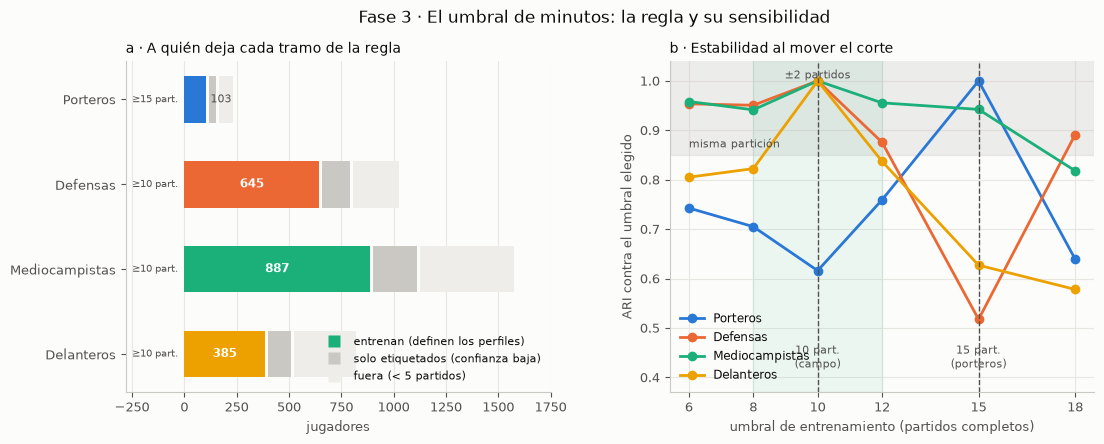

In [9]:
# ===== Evidencia de la decisión 1: el umbral de minutos =====
# (a) a quién deja cada tramo de la regla · (b) ARI al mover el corte de entrenamiento
visualizacion.figura_umbral(df_base, datasets,
                            guardar=R.figura("31_umbral_minutos.png"))

---
### 3.2 · Decisión 2 — el escalado

**El problema.** K-Means mide distancias euclídeas, así que **una sola variable puede dominar la partición** si su cola es más larga que la del resto. Las tasas por 90 son conteos divididos entre minutos: muchos ceros y cola derecha larga.

**Las dos opciones:**

- `StandardScaler` — centra y divide por la desviación. Iguala la escala, **no** la asimetría.
- `PowerTransformer(yeo-johnson, standardize=True)` — simetriza primero y estandariza después.

**Qué calcula la celda siguiente.** Toma el dataset de defensas —el caso más extremo—, aplica los dos escalados sobre las mismas tasas por 90 y compara:

- **(a) y (b)** la distribución de la variable más sesgada con cada escalado.
- **(c)** el **máx |z|** de cada variable con ambos. Ese es el criterio: mide a cuántas desviaciones queda el jugador más extremo y, por tanto, cuánto puede tirar él solo de un centroide. Cuanto más parejos los máx |z| entre variables, más equilibrado el peso de cada una en la distancia.

El resultado en defensas: la **asimetría media** de sus 8 variables pasa de **1.19** en bruto a **1.19** con `StandardScaler` —estandarizar no la toca— y a **0.04** con Yeo-Johnson.

> El pico de la izquierda en el panel (b) son los defensas con **cero asistencias**: ninguna transformación puede repartir una masa puntual. Lo que sí hace Yeo-Johnson es recortar la cola opuesta, que es la que desplazaba centroides.

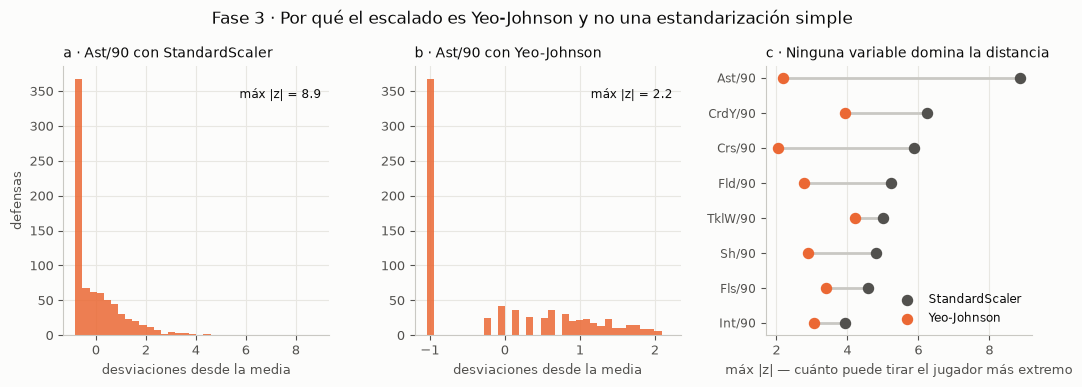

In [10]:
# ===== Evidencia de la decisión 2: el escalado =====
# La misma variable con StandardScaler y con Yeo-Johnson, y el máx |z| de todas.
visualizacion.figura_escalado(datasets, guardar=R.figura("32_escalado.png"))

---
### 3.3 · Decisión 3 — qué variables entran en cada modelo

**El problema.** Una variable puede parecer relevante y no aportar nada a la partición. Si no separa, solo añade una dimensión de ruido a la distancia euclídea.

**Qué calcula la celda siguiente.** Para cada posición, sobre el conjunto **candidato** (las variables del modelo más las que se probaron y quedaron fuera):

1. Ajusta el K-Means con todas las candidatas → partición de referencia.
2. Quita una variable, reajusta, y mide el **ARI** contra esa referencia.
3. ARI alto = los clusters no cambiaron = **la variable no estaba haciendo nada**.

El umbral práctico es **0.90**. Ojo con un detalle: la silueta casi siempre sube al quitar variables (menos dimensiones, menos concentración de distancias), así que el criterio es el ARI, no la silueta.

**Qué se ve en la figura.** Solo dos barras superan 0.90, ambas en gris:

- `G-PK`/90 en **defensas** — un defensa marca 0.05 goles por 90, dos o tres por temporada, donde el rebote afortunado pesa tanto como el rol. `Ast`/90 tiene frecuencia parecida (0.06 por 90) y **sí se queda**: asistir desde el lateral es repetible de una forma en que marcar de córner no lo es.
- `SoT%` en **mediocampistas** — la puntería solo define un rol donde el volumen de tiro es alto y parejo. En una posición que va del pivote (0.84 tiros/90) al llegador (2.31), lo que separa es *cuánto* se tira. En delanteros se invierte, y por eso allí `SoT%` sí entra.

El resto de exclusiones (redundancia y sucesos demasiado raros) se justifica en la sección de cada posición, porque son argumentos de correlación y de frecuencia, no de esta prueba.

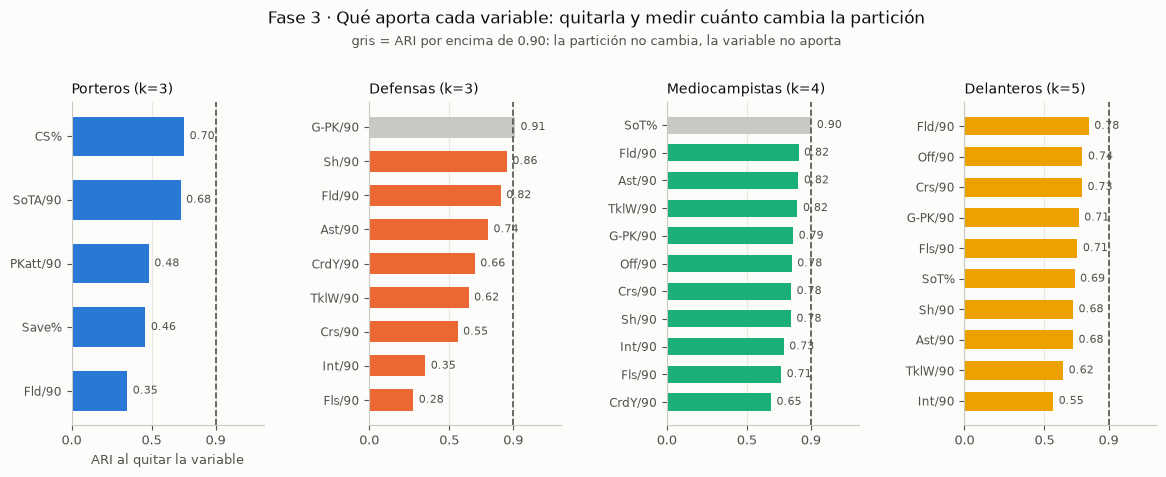

In [11]:
# ===== Evidencia de la decisión 3: qué variables entran =====
# Se quita cada candidata y se mide cuánto cambia la partición (ARI).
visualizacion.figura_ablacion(datasets, guardar=R.figura("33_ablacion_variables.png"))

---
## 4. Modelo de porteros (GK)

### Fase 3 · variables (5)

| Eje | Variables | Qué captura |
|---|---|---|
| **Carga de trabajo** | `SoTA`/90 | Cuántos tiros a puerta le llegan — de rebote, lo expuesto que está el equipo |
| **Habilidad** | `Save%` | Qué proporción de esos tiros detiene |
| **Resultado** | `CS%` | Partidos resueltos con la portería a cero |
| **Área** | `PKatt`/90, `Fld`/90 | Penaltis enfrentados y disputas en las que se le hace falta |

- **`Save%`** es la única que no depende de lo bien que defienda el equipo: correlaciona −0.17 con la carga de trabajo. Es el eje limpio de habilidad individual frente a tres ejes de contexto.
- **`Fld`/90** es un **proxy limitado** de cuánto sale el portero a disputar: no mide salidas directamente —esa métrica no está en `keeper` básica—, pero las faltas a un portero se producen casi siempre en balones aéreos y centros peleados. Es la variable más independiente del conjunto (correlación máxima 0.21) y el único indicio de *estilo* y no de resultado.

### Lo que queda fuera

Es la posición donde más cuesta elegir: casi todo lo que publica `keeper` mide el mismo fenómeno de fondo, lo que encaja el equipo.

| Variable | Motivo |
|---|---|
| `Saves`/90 | Correlaciona **0.93** con `SoTA`/90 — son los tiros recibidos por el % de parada |
| `GA90` | **0.84** con `SoTA`/90, **−0.67** con `Save%`, **−0.81** con `CS%`: casi determinada por las otras tres |
| `Penalty Kicks_Save%` | 49 % de porteros en cero; con <5 penaltis por temporada salta entre 0 % y 100 % sin reflejar nivel |
| `Int`/90, `TklW`/90 | Habrían sido el proxy del portero-líbero, pero el 68-74 % no registra ninguna en la temporada |
| `W` / `D` / `L` | Describen el resultado del equipo, no la actuación del portero |

La figura siguiente lo muestra: `Saves`/90 y `GA90` rebasan la banda de **redundancia**, y `PK Save%`, `Int`/90 y `TklW`/90 la de **escasez**. `W`/`D`/`L` no aparecen porque su exclusión es conceptual —miden al equipo— y no hay métrica que la demuestre.

> ⚠️ **Limitación.** `keeper` básica no trae PSxG, ni salidas del área contabilizadas, ni juego con los pies. Este modelo separa por *cuánto se les exige* y *qué proporción resuelven*, no por estilo con balón. Perfilar "portero-líbero" vs. "portero de línea" requeriría `keeper_adv`.

### Fases 4-5

- Centroides ajustados con los **103 porteros de entrenamiento**; se etiqueta a los **137** que superan 450 minutos.
- Un `k` alto produciría grupos de una decena de jugadores: anécdota, no perfil.
- `k=3` deja los tres clusters equilibrados y es **el `k` más bajo en el que el eje de salidas al área aparece como grupo propio** — con `k=2` el modelo solo puede cortar por el eje de exigencia.

Dataset Porteros: 137 jugadores (103 de entrenamiento)
  3 de 5 columnas convertidas a por-90 | 0 faltantes imputados | escalado: yeo-johnson
  Matriz final: 137 jugadores × 5 variables (103 de entrenamiento, 34 de confianza baja)


,% ceros,asimetría por-90,asimetría escalada,max |z| (entren.),max |z| (todos)
SoTA/90,0.0,0.36,0.01,2.99,3.31
Save%,0.0,-0.04,0.00,2.85,4.46
CS%,5.1,0.58,-0.03,2.36,3.21
PKatt/90,10.9,0.28,0.01,2.25,4.61
Fld/90,12.4,0.77,0.04,2.39,2.39


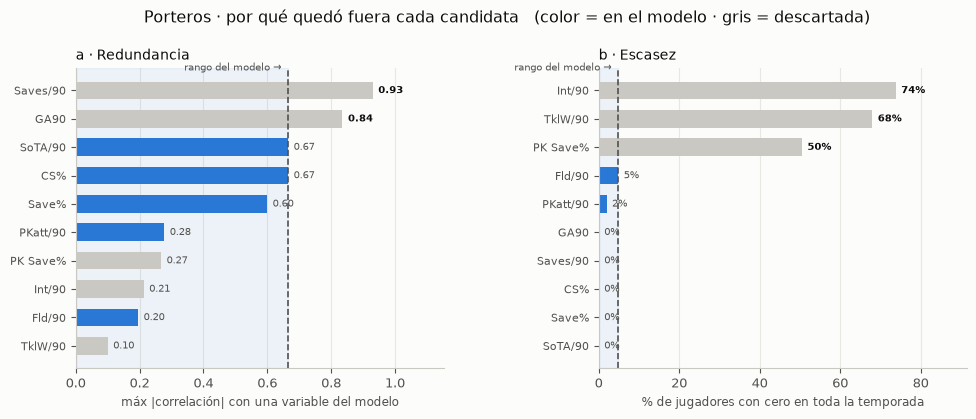

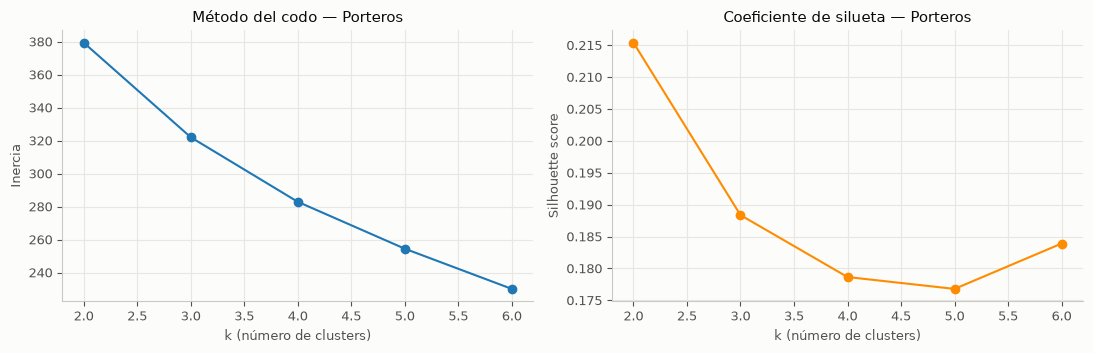

 k  inercia  silueta
 2    379.4    0.215
 3    322.0    0.188
 4    282.9    0.179
 5    254.5    0.177
 6    230.1    0.184

k con mejor silueta (solo referencia): 2
k sugerido por silueta: 2  |  k elegido: 3

=== Porteros — k=3 | n=137 | silhouette=0.188 ===
    103 de entrenamiento (silueta 0.188) | 34 etiquetados por predicción (silueta del conjunto completo 0.171)

Tamaño de cada cluster (etiquetados / de los cuales entrenan):
         etiquetados  entrenan
cluster                       
0                 44        38
1                 46        32
2                 47        33


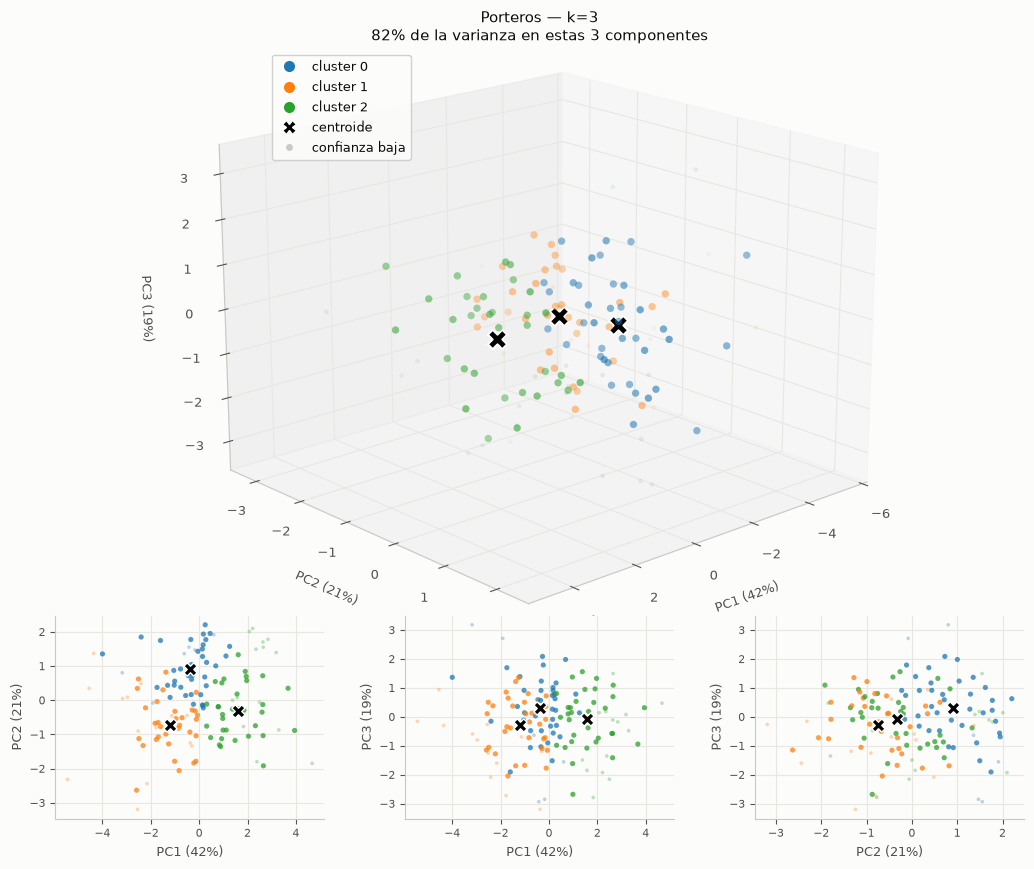

,varianza explicada,acumulada
PC1,42.3%,42.3%
PC2,20.9%,63.1%
PC3,18.8%,82.0%


Cargas de cada variable en las componentes (signo = dirección del eje):


,PC1,PC2,PC3
SoTA/90,-0.54,-0.10,0.32
Save%,0.46,-0.04,0.62
CS%,0.63,-0.11,0.17
PKatt/90,-0.26,-0.67,0.45
Fld/90,-0.19,0.72,0.53


Perfil medio de cada cluster (valores por 90 minutos, sin escalar):


,media global,cluster 0,cluster 1,cluster 2
SoTA/90,4.455,4.656,5.100,3.636
Save%,67.571,67.495,63.028,72.087
CS%,22.488,18.439,13.254,35.317
PKatt/90,0.155,0.130,0.224,0.110
Fld/90,0.130,0.210,0.099,0.085


Jugadores más representativos de cada cluster (solo de entrenamiento):
  cluster 0: Steve Mandanda, Matt Turner, Maduka Okoye, Michael Zetterer, Wladimiro Falcone, Alexandre Oukidja
  cluster 1: Stefano Turati, Luís Maximiano, Frederik Rønnow, Robert Sánchez, Kevin Müller, Bernd Leno
  cluster 2: Álex Remiro, Giorgi Mamardashvili, Łukasz Skorupski, Wojciech Szczęsny, Pietro Terracciano, Benjamin Lecomte

Confianza baja mejor encajados en su perfil (candidatos a revisar):


,player,team,age,Playing Time_Min,cluster,dist_centroide
0,Marko Dmitrović,Sevilla,31.0,1170.0,1,0.82
1,Etrit Berisha,Empoli,34.0,1260.0,1,1.57
2,Benoît Costil,Salernitana,36.0,1170.0,1,1.71
3,Marco Sportiello,Milan,31.0,630.0,1,1.91
4,Péter Gulácsi,RB Leipzig,33.0,1170.0,2,2.34
5,Pierluigi Gollini,Napoli,28.0,630.0,0,2.48
6,Juan Musso,Atalanta,29.0,990.0,2,2.49
7,Jiří Pavlenka,Werder Bremen,31.0,630.0,1,2.52


Porteros        -> jugadores_GK_con_cluster.csv, perfil_clusters_GK.csv, modelo_GK.joblib


In [12]:
# ===== FASES 3 a 6 — el modelo de porteros de principio a fin =====
# El código está en models/modelo_gk.py: prepara las variables, elige k, ajusta el
# K-Means, lo evalúa y exporta el dataset etiquetado, la tabla de perfiles y el .joblib.
from models import modelo_gk

modelos = {}   # se irá llenando en las secciones 4 a 7

modelos["GK"] = modelo_gk.main(datasets=datasets)

### Interpretación

**k=3 · silhouette 0.188** (103 de entrenamiento) · **0.171** (137 etiquetados) — el más alto de los cuatro modelos.

| Cluster | Perfil | n | Rasgos | Representativos |
|---|---|---|---|---|
| **2** | Portero de **bloque sólido** | 47 | Menor carga (`SoTA`/90 = 3.64 vs. media 4.46), mejor `Save%` (72.1 %), `CS%` 35.3 % vs. media 22.5 % | Oblak, Szczęsny, Remiro, Mamardashvili, Skorupski, Nübel |
| **1** | Portero **muy exigido** | 46 | Mayor carga (5.10), peor `Save%` (63.0 %), `CS%` 13.3 %, más penaltis enfrentados (0.224/90) | Turati, Maximiano, Rønnow, R. Sánchez, Leno, Mvogo |
| **0** | Portero **de área** | 44 | `Fld`/90 = **0.210 vs. 0.099 y 0.085** — más del doble; carga, `Save%` y penaltis en la media | Mandanda, Vicario, Turner, Falcone, Okoye, Zetterer |

**El cluster 0 es el que justifica el modelo.**
- Los clusters 1 y 2 son las dos puntas del eje de exigencia, que es en buena medida un eje de calidad de equipo.
- El 0 es lo único que se parece a un rasgo de **estilo**: no se define por lo que encaja sino por cuánto sale a disputar.
- Solo aparece porque los centroides se entrenan con porteros bien medidos; con las tasas ruidosas de quien lleva cinco partidos quedaba mezclado con los otros dos.

**La PCA lo confirma.**
- **PC1 (42.3 %)** — eje de exigencia y resultado: `CS%` (+0.63) y `Save%` (+0.46) contra `SoTA`/90 (−0.54).
- **PC2 (20.9 %)** — dominada por `Fld`/90 (+0.72) y `PKatt`/90 (−0.67): actividad en el área frente a penaltis concedidos. Dimensión con vida propia, independiente de lo que encaja el equipo. Ahí vive el cluster 0.

> ⚠️ **No es un ranking de calidad.** `CS%` y `SoTA`/90 dependen muchísimo del bloque defensivo. El indicador más individual sigue siendo `Save%`, y aun así conserva −0.17 con la carga recibida. Y salir mucho no es mejor ni peor que quedarse en la línea: es otra forma de defender el área.

**Uso para scouting.** Los 34 porteros de confianza baja son mayormente suplentes de temporada corta. La tabla de "mejor encajados en su perfil" los ordena por cercanía al centroide: los primeros son los de lectura de rol más limpia pese a la muestra corta.

---
## 5. Modelo de defensas (DF)

### Fase 3 · variables (8, todas por 90 minutos)

| Bloque | Variables |
|---|---|
| **Acción defensiva** | `Int`/90 (intercepciones), `TklW`/90 (entradas ganadas) |
| **Roce y disciplina** | `Fls`/90 (faltas cometidas), `Fld`/90 (recibidas), `CrdY`/90 (amarillas) |
| **Aporte ofensivo** | `Crs`/90 (centros), `Ast`/90, `Sh`/90 |

- El eje que más separa es **central vs. lateral**. `Crs`/90 es su marcador más nítido: media 1.5 con dispersión de 0 a más de 10.
- `Int`/90 y `CrdY`/90 marcan al central de área.
- **`Fls`/90 y `CrdY`/90 conviven** pese a correlacionar 0.51: miden volumen de falta y *gravedad*. Falta táctica lejos del área y llegar tarde dentro de ella dan `Fls`/90 parecido y `CrdY`/90 muy distinto.

### Lo que queda fuera

| Variable | Motivo |
|---|---|
| `Off`/90 | Solo en esta posición: el **40 %** de los defensas no cae en fuera de juego ni una vez. En MF y FW sí entra |
| `SoT%` | La mediana de tiros a puerta de un defensa en la temporada es **3**: su puntería es accidente de muestra, no rasgo de rol |
| `G-PK`/90 | **Estuvo dentro y se retiró** (ver abajo) |

En la figura siguiente, `SoT`/90 rebasa la banda de **redundancia** (0.74 con `Sh`/90) y `CrdR`/90 la de **escasez** (78 % de defensas sin ninguna roja). `Off`/90 y `SoT%` caben dentro de ambas bandas: su exclusión no es por redundancia ni por escasez, sino porque no separan roles — el mismo criterio que retiró a `G-PK`/90.

**Por qué se retiró `G-PK`/90.** Parecía razonable —debía captar al central que remata a balón parado— pero no discriminaba:
- Explica el **1 %** de la separación entre clusters.
- Al quitarla la partición queda prácticamente idéntica (**ARI 0.91**) y la silueta sube de 0.152 a **0.172**.
- Motivo: un defensa marca 0.05 goles por 90 — dos o tres goles por temporada, donde el rebote afortunado pesa tanto como el rol.
- `Ast`/90 tiene frecuencia parecida (0.06 por 90) y **sí se queda**, con poder discriminante siete veces mayor (0.37 vs. 0.01): asistir desde el lateral es repetible de una forma en que marcar de córner no lo es.

> Este dataset incluye a los polivalentes `DF,MF` y `MF,DF`, que también se evalúan en la sección 6 con variables de mediocampista.

### Fases 4-5

- La silueta sugiere `k=2` (central / lateral), correcto pero poco informativo: eso ya lo sabíamos.
- Con **`k=3`** el bloque de laterales se desdobla por estilo —proyección o duelo— sin que ningún grupo repita a otro.
- Se probó `k=4`, pero el cuarto cluster reproducía el perfil del central y la silueta bajaba a 0.132.
- Centroides con los **645 de entrenamiento**; etiquetados **779**.

Dataset Defensas: 779 jugadores (645 de entrenamiento)
  6 de 8 columnas convertidas a por-90 | 0 faltantes imputados | escalado: yeo-johnson
  Matriz final: 779 jugadores × 8 variables (645 de entrenamiento, 134 de confianza baja)


,% ceros,asimetría por-90,asimetría escalada,max |z| (entren.),max |z| (todos)
Int/90,0.0,0.60,0.00,3.00,3.06
TklW/90,0.1,0.69,0.00,3.70,4.21
Fls/90,0.0,0.54,-0.00,2.82,3.40
Fld/90,1.5,1.47,0.02,2.77,2.77
CrdY/90,5.3,0.57,0.01,2.62,3.93
Crs/90,8.0,1.70,0.20,1.97,2.04
Ast/90,47.2,1.60,0.30,2.09,2.18
Sh/90,1.5,1.43,0.02,2.88,2.88


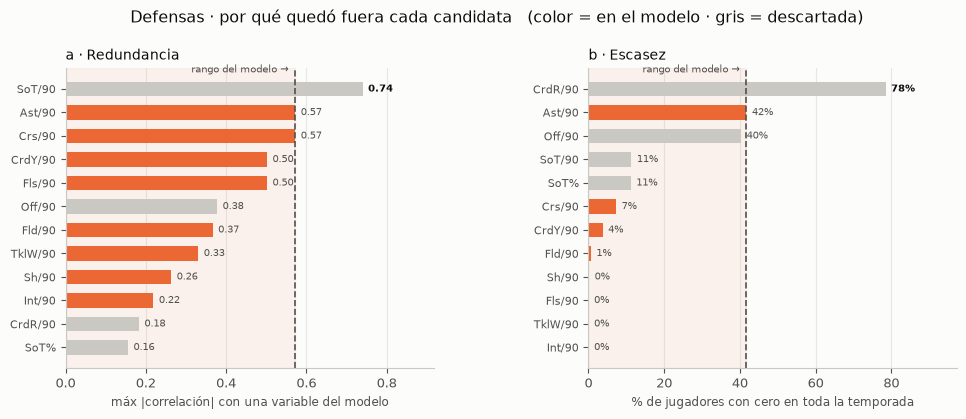

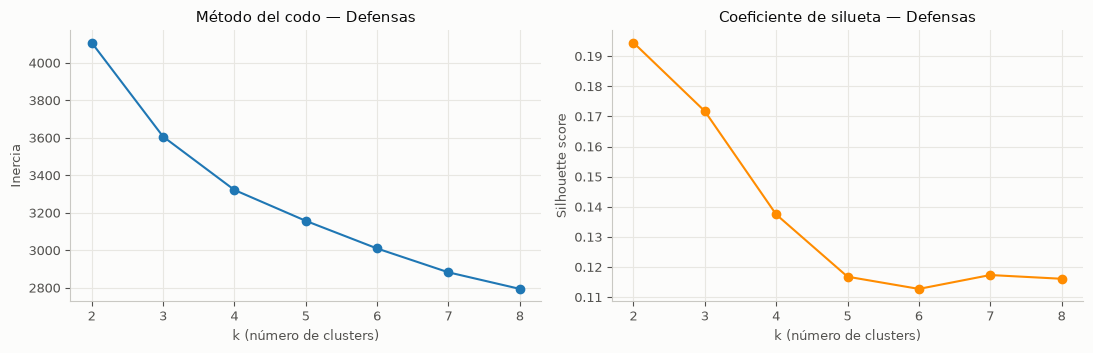

 k  inercia  silueta
 2   4107.9    0.194
 3   3606.9    0.172
 4   3322.1    0.137
 5   3157.3    0.117
 6   3009.8    0.113
 7   2882.6    0.117
 8   2794.3    0.116

k con mejor silueta (solo referencia): 2
k sugerido por silueta: 2  |  k elegido: 3

=== Defensas — k=3 | n=779 | silhouette=0.172 ===
    645 de entrenamiento (silueta 0.172) | 134 etiquetados por predicción (silueta del conjunto completo 0.161)

Tamaño de cada cluster (etiquetados / de los cuales entrenan):
         etiquetados  entrenan
cluster                       
0                216       163
1                321       271
2                242       211


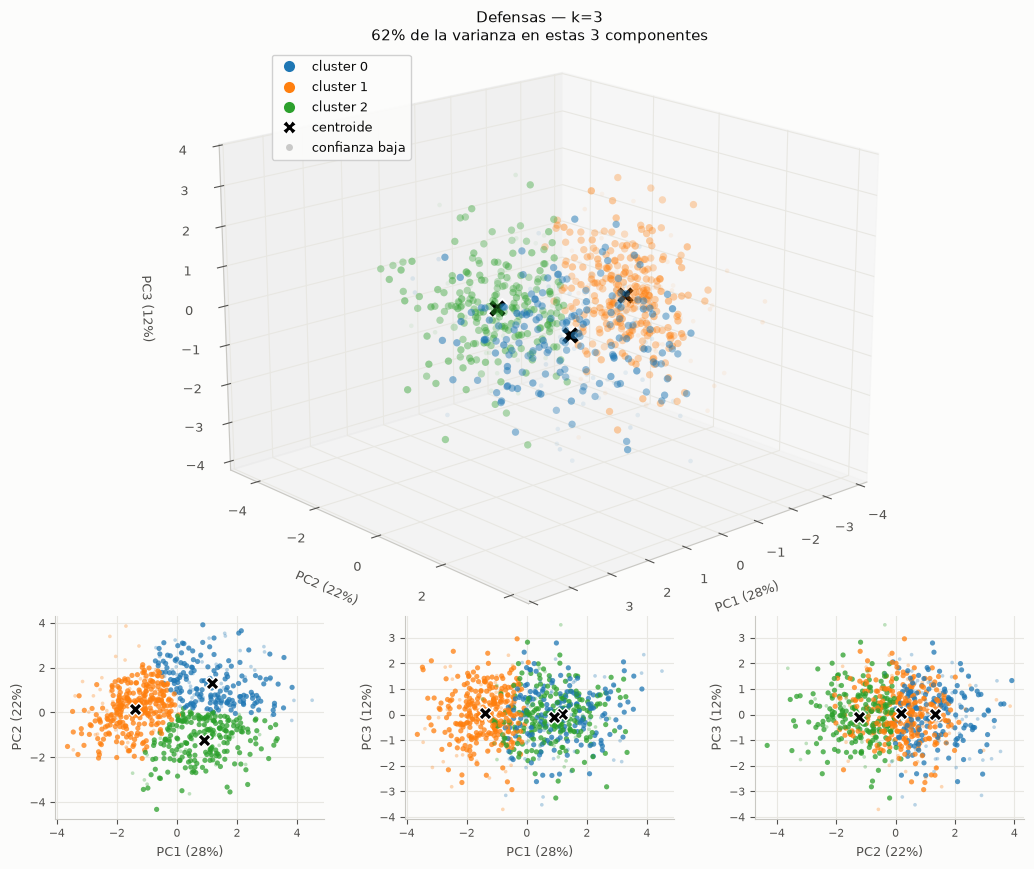

,varianza explicada,acumulada
PC1,28.5%,28.5%
PC2,21.9%,50.4%
PC3,12.1%,62.4%


Cargas de cada variable en las componentes (signo = dirección del eje):


,PC1,PC2,PC3
Int/90,0.02,0.46,0.67
TklW/90,0.44,0.16,0.28
Fls/90,0.32,0.49,-0.24
Fld/90,0.41,0.06,-0.07
CrdY/90,0.19,0.51,-0.46
Crs/90,0.48,-0.34,-0.11
Ast/90,0.41,-0.36,-0.06
Sh/90,0.32,-0.13,0.43


Perfil medio de cada cluster (valores por 90 minutos, sin escalar):


,media global,cluster 0,cluster 1,cluster 2
Int/90,1.044,1.285,1.055,0.816
TklW/90,1.125,1.445,0.879,1.164
Fls/90,1.071,1.462,0.928,0.913
Fld/90,0.771,1.042,0.519,0.862
CrdY/90,0.223,0.336,0.189,0.167
Crs/90,1.519,1.481,0.317,3.147
Ast/90,0.058,0.053,0.016,0.120
Sh/90,0.609,0.677,0.459,0.746


Composición de cada cluster por posición reportada (%):


pos,DF,"DF,MF","MF,DF"
cluster,,,
0,60.6,22.7,16.7
1,91.9,6.2,1.9
2,43.8,24.4,31.8


Jugadores más representativos de cada cluster (solo de entrenamiento):
  cluster 0: Nicolás Tagliafico, Nélson Semedo, Melvin Bard, Alfonso Espino, Giovanni González, Formose Mendy
  cluster 1: Philipp Lienhart, Cenk Özkacar, Ismaël Doukouré, Leny Yoro, Chrislain Matsima, Willi Orban
  cluster 2: Marius Wolf, Milos Kerkez, Angeliño, Rick Karsdorp, Vitaly Janelt, Luca Netz

Confianza baja mejor encajados en su perfil (candidatos a revisar):


,player,team,age,Playing Time_Min,cluster,dist_centroide
0,Joël Matip,Liverpool,31.0,781.0,1,1.06
1,Serge Aurier,Nottingham,30.0,833.0,2,1.44
2,Josh Wilson-Esbrand,Reims,20.0,461.0,2,1.44
3,Pantelis Hatzidiakos,Cagliari,26.0,856.0,1,1.45
4,Sadibou Sané,Metz,19.0,846.0,1,1.69
5,Bruno Amione,Hellas Verona,21.0,579.0,0,1.78
6,Silvan Hefti,Montpellier,25.0,711.0,2,1.79
7,Isak Hien,Hellas Verona,24.0,864.0,1,1.82


Defensas        -> jugadores_DF_con_cluster.csv, perfil_clusters_DF.csv, modelo_DF.joblib


In [13]:
# ===== FASES 3 a 6 — el modelo de defensas de principio a fin =====
# El código está en models/modelo_df.py: prepara las variables, elige k, ajusta el
# K-Means, lo evalúa y exporta el dataset etiquetado, la tabla de perfiles y el .joblib.
from models import modelo_df

modelos["DF"] = modelo_df.main(datasets=datasets)

### Interpretación

**k=3 · silhouette 0.172** (645 de entrenamiento) · **0.161** (779 etiquetados).

El eje dominante sigue siendo central vs. lateral, y el desdoble separa a los laterales por **estilo** en vez de duplicar un perfil.

| Cluster | Perfil | n | Rasgos | Representativos |
|---|---|---|---|---|
| **1** | **Central** | 321 | `Crs`/90 = 0.32 vs. media 1.52 — el más bajo con diferencia. También mínimos en `Fld`/90 (0.52), `Sh`/90 (0.46), `Ast`/90 (0.016) y `TklW`/90 (0.88). 91.9 % `DF` puro | Lienhart, Özkacar, Doukouré, Yoro, Matsima, Orban |
| **2** | **Carrilero ofensivo** | 242 | `Crs`/90 = 3.15 y `Ast`/90 = 0.120, los más altos. Mínimos en `Int`/90 (0.82), `Fls`/90 (0.91) y `CrdY`/90 (0.167). 56.2 % polivalentes | Kerkez, Angeliño, Wolf, Karsdorp, Janelt, Netz |
| **0** | **Lateral de combate** | 216 | Lidera las cuatro métricas de duelo: `Int`/90 1.29, `TklW`/90 1.45, `Fls`/90 1.46, `CrdY`/90 0.336, más `Fld`/90 1.04. `Crs`/90 en la media (1.48) | Tagliafico, Semedo, Bard, Espino, González, Mendy |

- **`Fls`/90 × `CrdY`/90:** el cluster 0 combina los máximos de ambas — llegar tarde en zonas de disputa, más que falta táctica lejos del área.
- **Por qué `k=3` y no `k=4`:** con cuatro clusters aparecía un grupo cuyo perfil replicaba al del central sin rasgo propio, y la silueta bajaba.

> ⚠️ Con silhouette 0.172 los límites no son tajantes: hay defensas en la frontera entre "carrilero ofensivo" y "lateral de combate" que un cambio pequeño movería de cluster. Es además la posición con más confianza baja después de porteros (134 de 779), coherente con ser la más sensible al ruido de muestra corta.

---
## 6. Modelo de mediocampistas (MF)

### Fase 3 · variables (10)

Tensan el eje **destrucción ↔ creación ↔ llegada**, donde vive la variedad de roles del mediocampo.

| Bloque | Variables |
|---|---|
| **Recuperación** | `Int`/90, `TklW`/90 |
| **Roce** | `Fls`/90, `Fld`/90, `CrdY`/90 |
| **Creación** | `Ast`/90, `Crs`/90 |
| **Llegada / gol** | `G-PK`/90, `Sh`/90, `Off`/90 |

- Es la posición con más variables, y con razón: **`Int`/90 correlaciona −0.46 con `Sh`/90**, o sea que recuperar y rematar son polos opuestos de un mismo eje continuo. Hacen falta variables a ambos lados para situar a cada jugador en él.
- **`Fld`/90** es el mejor proxy de **conducción** disponible: a quien rompe líneas con el balón lo frenan a falta. Sin la tabla `possession` no hay regates ni conducciones progresivas.
- **`Off`/90** separa al mediapunta que ataca el área del interior que juega de cara; solo el 25 % nunca cae en fuera de juego, así que tiene recorrido suficiente.

### Lo que queda fuera

| Variable | Motivo |
|---|---|
| `SoT`/90 | Correlaciona **0.91** con `Sh`/90: duplicaría el peso del volumen de remate |
| `SoT%` | **Estuvo dentro y se retiró** (ver abajo) |

En la figura siguiente, `SoT`/90 rebasa la banda de **redundancia** (0.91 con `Sh`/90), y `PKatt`/90 y `CrdR`/90 la de **escasez** (85 % de mediocampistas sin ninguno). `SoT%` cabe dentro de ambas: se descartó por no aportar a la partición.

**Por qué se retiró `SoT%`.** Es independiente de `Sh`/90 (correlacionan 0.29), pero *independiente* no es *útil*:
- Explica el **15 %** de la partición, lo más bajo de las once variables que había.
- Al quitarla los clusters quedan prácticamente iguales (**ARI 0.91**) y la silueta sube de 0.130 a **0.141**.
- La puntería solo define un rol donde el volumen de tiro es alto y parejo. En una posición que va del pivote (0.84 tiros/90) al llegador (2.31), lo que separa es *cuánto* se tira, no *con qué acierto*.
- En delanteros la situación se invierte, y por eso allí `SoT%` sí entra.

> Es el dataset más grande de los cuatro: absorbe a todos los polivalentes `MF`, `MF,FW`, `FW,MF`, `DF,MF` y `MF,DF`.

### Fases 4-5

- Como en defensas, la silueta favorece `k=2` (ofensivo / defensivo).
- Con **`k=4`** aparecen además el carrilero y el interior de conducción.
- Centroides con los **887 de entrenamiento**; etiquetados **1097**.

Dataset Mediocampistas: 1097 jugadores (887 de entrenamiento)
  7 de 10 columnas convertidas a por-90 | 0 faltantes imputados | escalado: yeo-johnson
  Matriz final: 1097 jugadores × 10 variables (887 de entrenamiento, 210 de confianza baja)


,% ceros,asimetría por-90,asimetría escalada,max |z| (entren.),max |z| (todos)
Int/90,1.3,0.85,0.02,2.89,2.89
TklW/90,0.2,0.64,0.00,2.89,3.42
Fls/90,0.0,0.62,0.00,2.72,3.87
Fld/90,0.1,0.69,-0.00,2.83,3.68
CrdY/90,6.9,0.80,0.02,3.24,3.24
Crs/90,1.0,1.13,0.02,2.28,2.48
Off/90,27.3,2.00,0.29,2.12,2.12
Ast/90,25.0,1.23,0.10,2.67,2.67
G-PK/90,29.2,1.54,0.20,2.21,2.21
Sh/90,0.2,0.72,0.01,2.60,2.91


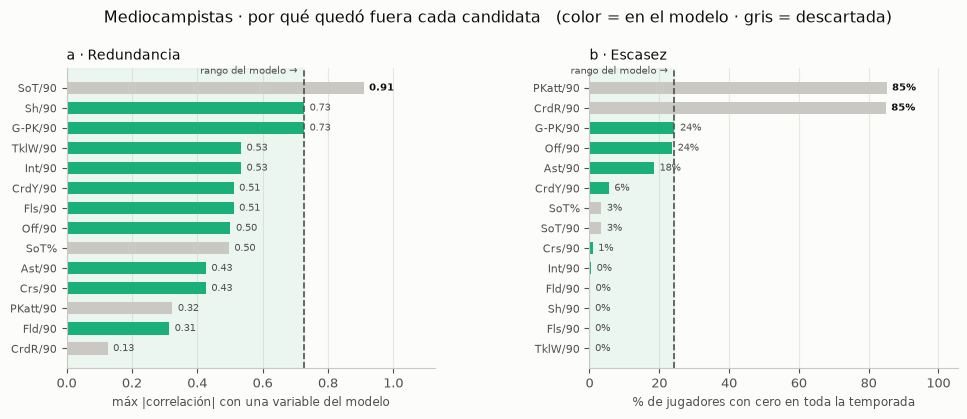

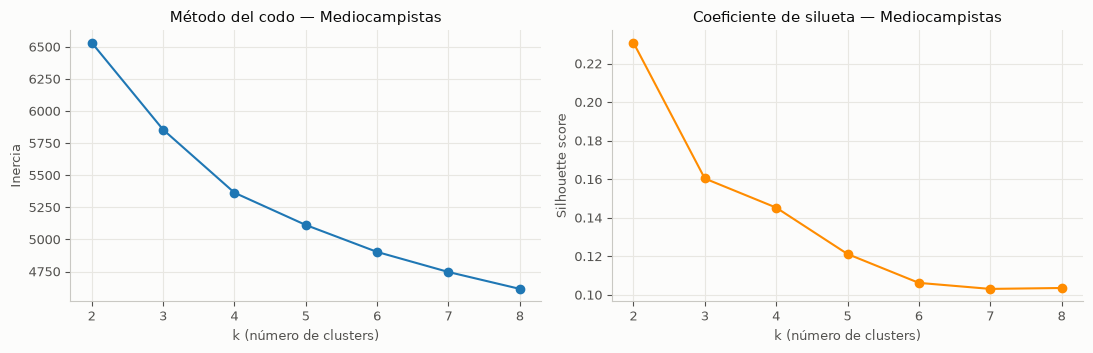

 k  inercia  silueta
 2   6532.6    0.231
 3   5855.4    0.160
 4   5363.9    0.145
 5   5112.4    0.121
 6   4902.4    0.106
 7   4746.1    0.103
 8   4614.5    0.104

k con mejor silueta (solo referencia): 2
k sugerido por silueta: 2  |  k elegido: 4

=== Mediocampistas — k=4 | n=1097 | silhouette=0.145 ===
    887 de entrenamiento (silueta 0.145) | 210 etiquetados por predicción (silueta del conjunto completo 0.135)

Tamaño de cada cluster (etiquetados / de los cuales entrenan):
         etiquetados  entrenan
cluster                       
0                267       225
1                250       190
2                271       226
3                309       246


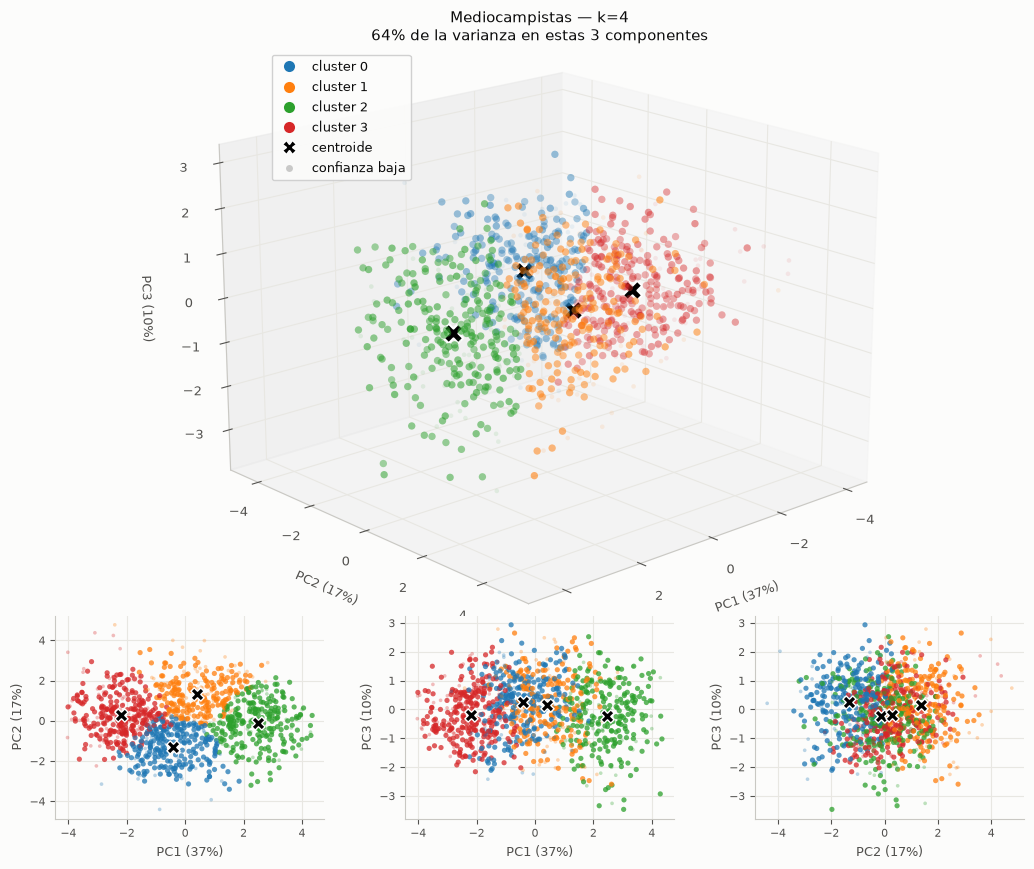

,varianza explicada,acumulada
PC1,36.6%,36.6%
PC2,17.0%,53.6%
PC3,10.1%,63.7%


Cargas de cada variable en las componentes (signo = dirección del eje):


,PC1,PC2,PC3
Int/90,-0.38,-0.03,0.15
TklW/90,-0.36,0.15,0.31
Fls/90,-0.21,0.57,0.04
Fld/90,0.11,0.51,0.20
CrdY/90,-0.25,0.43,0.17
Crs/90,0.27,-0.18,0.67
Off/90,0.35,0.19,-0.03
Ast/90,0.31,-0.06,0.54
G-PK/90,0.38,0.24,-0.25
Sh/90,0.40,0.29,-0.08


Perfil medio de cada cluster (valores por 90 minutos, sin escalar):


,media global,cluster 0,cluster 1,cluster 2,cluster 3
Int/90,0.755,0.793,0.632,0.387,1.145
TklW/90,1.093,1.092,1.114,0.637,1.478
Fls/90,1.275,0.923,1.617,0.942,1.593
Fld/90,1.319,0.897,1.835,1.390,1.204
CrdY/90,0.221,0.147,0.295,0.123,0.311
Crs/90,2.329,2.874,2.471,3.168,1.009
Off/90,0.174,0.096,0.250,0.329,0.043
Ast/90,0.119,0.116,0.113,0.205,0.051
G-PK/90,0.126,0.048,0.174,0.255,0.042
Sh/90,1.455,0.898,1.885,2.311,0.839


Composición de cada cluster por posición reportada (%):


pos,"DF,MF","FW,MF",MF,"MF,DF","MF,FW"
cluster,,,,,
0,24.0,0.7,44.2,25.1,6.0
1,2.8,12.4,51.6,6.0,27.2
2,0.4,29.5,33.6,1.8,34.7
3,18.1,0.0,68.9,10.4,2.6


Jugadores más representativos de cada cluster (solo de entrenamiento):
  cluster 0: Vitaly Janelt, Angeliño, Luca Netz, Manuel Lazzari, Adrien Truffert, Gabriele Zappa
  cluster 1: Enzo Fernández, Enzo Millot, Adrien Rabiot, Fabio Miretti, Emmanuel Sabbi, John McGinn
  cluster 2: Achraf Hakimi, Loum Tchaouna, Jamie Leweling, Noni Madueke, Martin Ødegaard, Armand Lauriente
  cluster 3: Pablo Barrios, Antonio Blanco, Djibril Sow, Alexis Blin, Junior Mwanga, Moisés Caicedo

Confianza baja mejor encajados en su perfil (candidatos a revisar):


,player,team,age,Playing Time_Min,cluster,dist_centroide
0,Hugo Álvarez,Celta Vigo,20.0,762.0,0,1.46
1,Viktor Kovalenko,Empoli,27.0,613.0,2,1.49
2,Gianluca Gaetano,Cagliari,23.0,745.0,2,1.59
3,Thomas Partey,Arsenal,30.0,788.0,3,1.74
4,Ivan Cavaleiro,Lille,29.0,770.0,2,1.77
5,Carles Pérez,Celta Vigo,25.0,772.0,1,1.80
6,Jérôme Roussillon,Union Berlin,30.0,752.0,0,1.90
7,Serge Aurier,Nottingham,30.0,833.0,0,1.94


Mediocampistas  -> jugadores_MF_con_cluster.csv, perfil_clusters_MF.csv, modelo_MF.joblib


In [14]:
# ===== FASES 3 a 6 — el modelo de mediocampistas de principio a fin =====
# El código está en models/modelo_mf.py: prepara las variables, elige k, ajusta el
# K-Means, lo evalúa y exporta el dataset etiquetado, la tabla de perfiles y el .joblib.
from models import modelo_mf

modelos["MF"] = modelo_mf.main(datasets=datasets)

### Interpretación

**k=4 · silhouette 0.145** (887 de entrenamiento) · **0.135** (1097 etiquetados). El más bajo de los cuatro, esperable en un mediocampo que es un continuo de roles más que categorías separadas.

| Cluster | Perfil | n | Rasgos | Representativos |
|---|---|---|---|---|
| **3** | **Pivote destructor** | 309 | Máximos en `Int`/90 (1.15) y `TklW`/90 (1.48); mínimos en `Crs`/90 (1.01), `Off`/90 (0.043), `Ast`/90 (0.051), `G-PK`/90 (0.042) y `Sh`/90 (0.84). Casi nunca pisa el área rival. 68.9 % `MF` puro | Caicedo, Sow, Barrios, Blanco, Blin, Mwanga |
| **2** | **Interior ofensivo** | 271 | Lidera `Crs`/90 (3.17), `Off`/90 (0.329), `Ast`/90 (0.205), `G-PK`/90 (0.255) y `Sh`/90 (2.31); mínimos en `Int`/90 (0.387), `TklW`/90 (0.637) y amarillas. 64.2 % `MF,FW`/`FW,MF` | Ødegaard, Hakimi, Madueke, Lauriente, Tchaouna, Minamino |
| **0** | **Carrilero** | 267 | `Crs`/90 alto (2.87) pero sin llegada: `Sh`/90 0.90, `G-PK`/90 0.048, `Off`/90 0.096 y el `Fld`/90 más bajo (0.90). 49.1 % `DF,MF`/`MF,DF` | Angeliño, Netz, Lazzari, Truffert, Janelt, Zappa |
| **1** | **Interior de conducción** | 250 | Máximos en `Fld`/90 (1.84) y `Fls`/90 (1.62) — el de mayor roce en ambas direcciones — con remate sobre la media (`Sh`/90 1.89) | Enzo Fernández, Rabiot, Millot, Miretti, McGinn |

- **El eje que ordena el mediocampo** va del cluster 3 al 2: `Int`/90 correlaciona −0.46 con `Sh`/90, así que recuperar y rematar son los dos polos de un continuo.
- Los clusters 0 y 1 son posiciones intermedias que se distinguen por *cómo* participan: el 0 por banda y sin llegada, el 1 por el centro y a base de roce.
- **Cruce con la sección 7:** el cluster 2 concentra a la mayoría de los `MF,FW`/`FW,MF` — señal de que el modelo captura su polivalencia ofensiva. Contrastar con la tabla `polivalentes_clusters` de la sección 8.

> ⚠️ Con silhouette 0.145, el mediocampo es la posición con menos fronteras naturales entre roles. Etiquetas de trabajo, no veredicto.

---
## 7. Modelo de delanteros (FW)

### Fase 3 · variables (10)

| Bloque | Variables |
|---|---|
| **Finalización** | `G-PK`/90, `Sh`/90, `SoT%` |
| **Movimiento** | `Off`/90 (fueras de juego) |
| **Juego de banda** | `Crs`/90 (centros), `Ast`/90 |
| **Conducción** | `Fld`/90 (faltas recibidas) |
| **Trabajo sin balón** | `Int`/90, `TklW`/90, `Fls`/90 |

- **`Off`/90** es el marcador del **delantero de ruptura**: caer en fuera de juego es el precio de atacar el espacio a la espalda de la defensa, y separa al nueve de área del extremo que recibe de cara. Es la variable con más recorrido de la posición: media 0.46 por 90 y solo 3.4 % a cero.
- **`Int`/90 y `TklW`/90** son un bloque deliberado: distinguen al **atacante que presiona** del finalizador puro. Correlacionan −0.26 y −0.29 con `Sh`/90 — dentro del ataque, defender y rematar tiran en direcciones opuestas. Es el eje que interesa a un scouting que busca delantero para presión alta.
- **`Sh`/90 + `SoT%`, no `SoT`/90.** Es la **única posición donde `SoT%` entra**, porque es donde todos rematan lo suficiente para que la puntería signifique algo: quitarla reorganiza la partición (ARI 0.60). Y la separación es la más limpia de todas — `Sh`/90 y `SoT%` correlacionan **0.13**, dos dimensiones casi independientes que juntas describen el perfil de tiro mejor que cualquiera por separado.

### Lo que queda fuera

| Variable | Motivo |
|---|---|
| `PKatt`/90 | El 65 % no lanza ninguno, y quien lanza es porque el club se lo asigna: decisión de vestuario, no forma de jugar |
| `CrdY`/90 | Correlaciona 0.44 con `Fls`/90 y las tarjetas no marcan rol de ataque. En DF y MF sí aportan |
| `SoT`/90, `G/Sh` | Redundantes con `Sh`/90 y `G-PK`/90 |

En la figura siguiente, `SoT`/90 (0.86) y `G/Sh` (0.70) rebasan la banda de **redundancia**, y `CrdR`/90 (86 %) y `PKatt`/90 (63 %) la de **escasez**. `CrdY`/90 cabe dentro de ambas: se descartó porque añadirla baja la silueta sin aportar un rol nuevo.

> Este dataset incluye a los `MF,FW` y `FW,MF`, que también se evalúan en la sección 6.

### Fases 4-5

Es la posición que admite más granularidad:

| `k` | Qué añade | Silhouette |
|---|---|---|
| 3 | Base: nueves, extremos y enlace | 0.160 |
| 4 | Separa los dos tipos de nueve y los dos de extremo | 0.134 |
| **5** | Aparece un quinto perfil que **no es subdivisión de ninguno** | **0.132** |
| 6 | — | 0.116 |

- El quinto rol sale **prácticamente gratis** (0.134 → 0.132); con `k=6` la caída ya es clara, así que cinco es el techo natural.
- Centroides con los **385 de entrenamiento**; etiquetados **496**.

Dataset Delanteros: 496 jugadores (385 de entrenamiento)
  6 de 10 columnas convertidas a por-90 | 0 faltantes imputados | escalado: yeo-johnson
  Matriz final: 496 jugadores × 10 variables (385 de entrenamiento, 111 de confianza baja)


,% ceros,asimetría por-90,asimetría escalada,max |z| (entren.),max |z| (todos)
G-PK/90,6.9,0.92,0.04,2.47,2.52
Ast/90,18.8,0.88,0.07,2.43,2.46
Sh/90,0.0,0.41,-0.00,3.01,3.20
SoT%,0.0,-0.06,0.03,3.44,4.51
Off/90,5.0,1.43,0.06,2.64,2.64
Crs/90,1.4,1.37,0.11,2.04,2.04
Fld/90,0.2,0.53,0.00,3.26,3.26
Fls/90,0.0,0.92,0.00,2.95,3.41
Int/90,6.7,1.46,0.05,3.03,3.03
TklW/90,1.0,0.95,0.03,2.71,3.43


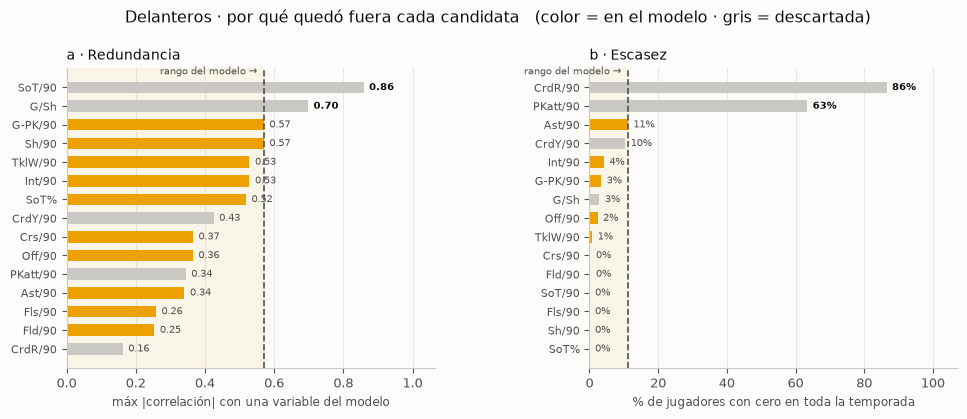

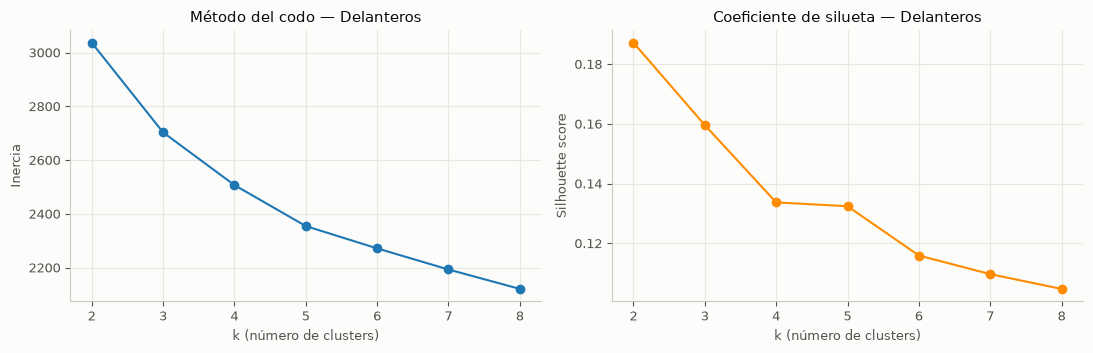

 k  inercia  silueta
 2   3037.0    0.187
 3   2703.3    0.160
 4   2507.1    0.134
 5   2354.7    0.132
 6   2271.6    0.116
 7   2193.1    0.110
 8   2120.9    0.105

k con mejor silueta (solo referencia): 2
k sugerido por silueta: 2  |  k elegido: 5

=== Delanteros — k=5 | n=496 | silhouette=0.132 ===
    385 de entrenamiento (silueta 0.132) | 111 etiquetados por predicción (silueta del conjunto completo 0.122)

Tamaño de cada cluster (etiquetados / de los cuales entrenan):
         etiquetados  entrenan
cluster                       
0                 74        59
1                124        83
2                119        88
3                105        90
4                 74        65


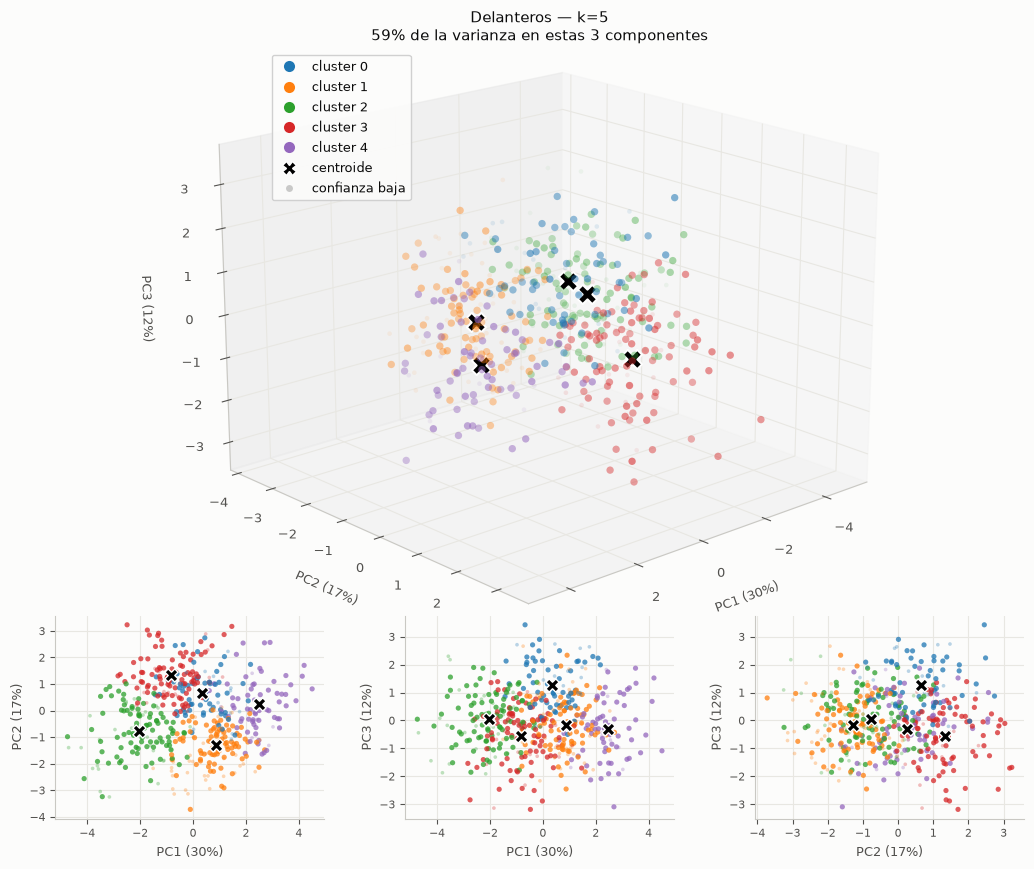

,varianza explicada,acumulada
PC1,30.2%,30.2%
PC2,16.7%,47.0%
PC3,12.1%,59.1%


Cargas de cada variable en las componentes (signo = dirección del eje):


,PC1,PC2,PC3
G-PK/90,0.43,0.15,0.33
Ast/90,-0.00,0.58,0.25
Sh/90,0.33,0.15,0.49
SoT%,0.34,0.17,0.05
Off/90,0.36,-0.18,0.06
Crs/90,-0.33,0.43,0.10
Fld/90,-0.17,-0.21,0.58
Fls/90,-0.04,-0.56,0.36
Int/90,-0.39,0.11,0.24
TklW/90,-0.42,-0.05,0.23


Perfil medio de cada cluster (valores por 90 minutos, sin escalar):


,media global,cluster 0,cluster 1,cluster 2,cluster 3,cluster 4
G-PK/90,0.280,0.443,0.259,0.139,0.194,0.503
Ast/90,0.145,0.246,0.069,0.089,0.225,0.146
Sh/90,2.393,2.988,2.584,1.707,2.255,2.774
SoT%,38.861,43.901,36.207,34.453,36.122,49.241
Off/90,0.458,0.443,0.604,0.261,0.312,0.755
Crs/90,1.852,1.779,0.674,2.030,3.942,0.648
Fld/90,1.574,1.794,1.604,1.891,1.275,1.216
Fls/90,1.330,1.354,1.704,1.600,0.796,1.006
Int/90,0.352,0.475,0.181,0.585,0.342,0.156
TklW/90,0.650,0.679,0.473,1.067,0.614,0.296


Composición de cada cluster por posición reportada (%):


pos,FW,"FW,MF","MF,FW"
cluster,,,
0,40.5,31.1,28.4
1,71.8,19.4,8.9
2,8.4,21.0,70.6
3,8.6,27.6,63.8
4,79.7,16.2,4.1


Jugadores más representativos de cada cluster (solo de entrenamiento):
  cluster 0: Matheus Cunha, Ademola Lookman, Cody Gakpo, Richarlison, Eberechi Eze, Kai Havertz
  cluster 1: Jørgen Strand Larsen, Steve Mounié, Oscar Vilhelmsson, Chris Ramos, Lorenzo Lucca, Thijs Dallinga
  cluster 2: Emmanuel Sabbi, Jean-Ricner Bellegarde, Pontus Almqvist, Habib Diarra, Facundo Pellistri, Rubén García
  cluster 3: Loum Tchaouna, Gonçalo Guedes, Kaoru Mitoma, Bryan Mbeumo, Florian Thauvin, Edon Zhegrova
  cluster 4: Nicolas Jackson, Ben Brereton, Elye Wahi, Terem Moffi, Ante Budimir, Benjamin Šeško

Confianza baja mejor encajados en su perfil (candidatos a revisar):


,player,team,age,Playing Time_Min,cluster,dist_centroide
0,Hugo Álvarez,Celta Vigo,20.0,762.0,2,1.80
1,Pedro,Lazio,36.0,816.0,2,1.94
2,Tomáš Čvančara,Gladbach,22.0,896.0,1,1.94
3,André Silva,Real Sociedad,27.0,729.0,1,2.01
4,David Datro Fofana,Burnley,20.0,879.0,4,2.08
5,Lukas Daschner,Bochum,24.0,536.0,3,2.09
6,Hugo Ekitike,Frankfurt,21.0,716.0,0,2.11
7,Arijon Ibrahimović,Frosinone,17.0,474.0,3,2.12


Delanteros      -> jugadores_FW_con_cluster.csv, perfil_clusters_FW.csv, modelo_FW.joblib


In [15]:
# ===== FASES 3 a 6 — el modelo de delanteros de principio a fin =====
# El código está en models/modelo_fw.py: prepara las variables, elige k, ajusta el
# K-Means, lo evalúa y exporta el dataset etiquetado, la tabla de perfiles y el .joblib.
from models import modelo_fw

modelos["FW"] = modelo_fw.main(datasets=datasets)

### Interpretación

**k=5 · silhouette 0.132** (385 de entrenamiento) · **0.122** (496 etiquetados).

Dos familias —extremos y nueves— más un perfil que las cruza.

| Cluster | Perfil | n | Rasgos | Representativos |
|---|---|---|---|---|
| **3** | **Extremo centrador** | 105 | `Crs`/90 = 3.94, más del doble de la media (1.85); `Ast`/90 0.225; las faltas cometidas más bajas (0.796). 91.4 % polivalentes | Mitoma, Mbeumo, Zhegrova, Guedes, Thauvin, Johnson |
| **2** | **Extremo de presión** | 119 | Lidera `Int`/90 (0.585), `TklW`/90 (1.067) y `Fld`/90 (1.891); el remate más bajo (`Sh`/90 1.71, `G-PK`/90 0.139, `SoT%` 34.5 %). 91.6 % polivalentes | Sabbi, Bellegarde, Almqvist, Diarra, Pellistri |
| **1** | **Nueve de choque** | 124 | `Fls`/90 más alto (1.704) y `Off`/90 alto (0.604), pero convierte mal: `Sh`/90 2.58 con `SoT%` 36.2 % y `G-PK`/90 0.259. `Ast`/90 más bajo (0.069). 71.8 % `FW` puro | Strand Larsen, Mounié, Lucca, Ramos, Dallinga, Prats |
| **4** | **Nueve de área** | 74 | Máximos en `G-PK`/90 (0.503), `SoT%` (49.2 %) y `Off`/90 (0.755); mínimos en `Crs`/90 (0.648), `Int`/90 (0.156), `TklW`/90 (0.296) y `Fld`/90 (1.216). 79.7 % `FW` puro, el más homogéneo | Jackson, Brereton, Wahi, Moffi, Budimir, Šeško, En-Nesyri |
| **0** | **Delantero asociativo** | 74 | `Sh`/90 más alto (2.99) y `G-PK`/90 0.443, cerca del nueve de área. Pero además centra (`Crs`/90 1.78), asiste (`Ast`/90 0.246, el mayor) y presiona (`Int`/90 0.475). 59.5 % polivalentes | Cunha, Lookman, Gakpo, Richarlison, Eze, Havertz, Bowen |

**El contraste 4 vs. 0 es el más accionable.**
- Marcan a ritmo parecido: 0.503 y 0.443 goles sin penalti por 90.
- El **4** lo consigue sin hacer nada más — tiene los mínimos de los cinco en centros, intercepciones, entradas y faltas recibidas.
- El **0** marca casi igual y además es el que más asiste de toda la posición.
- Para un informe de fichajes no son intercambiables aunque sus goles digan lo mismo: depende de si el sistema exige participación fuera del área.

**`Sh`/90 × `SoT%` con cinco grupos:** cluster 4 = volumen alto + mejor puntería (49.2 %); cluster 1 = volumen parecido + puntería baja (36.2 %); cluster 2 = volumen bajo + la puntería más baja (34.5 %). Es el cruce que justifica haber elegido `Sh`/90 y `SoT%` en lugar de `Sh`/90 y `SoT`/90.

> ⚠️ El cluster 0 concentra delanteros de equipos grandes (Havertz, Gakpo, Bowen, Lookman), así que parte de lo que separa "asociativo" de "área pura" puede ser estilo de equipo y no del jugador — el mismo cuidado que en porteros con `CS%`. Y con silhouette 0.132 los límites entre perfiles vecinos no son tajantes.

---
## 8. Evaluación comparativa y despliegue (*Evaluation* · *Deployment*)

Las cuatro secciones anteriores evaluaron cada modelo por separado. Aquí se comparan entre sí y se exporta todo lo necesario para reutilizar el análisis.

> ⚠️ **El `silhouette` no es comparable entre posiciones.** Cada modelo trabaja en un espacio distinto, con distinto número de variables y de jugadores. Un silhouette bajo en mediocampistas no significa peor modelo, sino que el mediocampo es un continuo de roles sin fronteras naturales — exactamente lo que uno esperaría del fútbol. Sirve para comparar `k` **dentro** de una posición, no entre posiciones.

In [16]:
# --- Comparación de los 4 modelos ------------------------------------------------------
mostrar(modelado.comparar_modelos(modelos))

total_perfiles = sum(modelos[p]["k"] for p in P.POSICIONES)
print(f"Total de perfiles identificados en las 4 posiciones: {total_perfiles}")

# --- Los polivalentes, vistos desde sus dos modelos ------------------------------------
# Un jugador "DF,MF" tiene un cluster como defensa y otro como mediocampista. Esta tabla
# los pone lado a lado: es la lectura más útil del enfoque por posición, porque muestra
# qué rol cumple el mismo futbolista según desde qué línea se le mire.
polivalentes_clusters = modelado.clusters_de_polivalentes(modelos, polivalentes)

print(f"\nJugadores polivalentes con doble etiqueta: {len(polivalentes_clusters)}")
mostrar(polivalentes_clusters.head(15))

,posición,n_etiquetados,n_entrenan,n_variables,k,sil_entren.,sil_todos,cluster más grande,cluster más pequeño
0,Porteros,137,103,5,3,0.188,0.171,47,44
1,Defensas,779,645,8,3,0.172,0.161,321,216
2,Mediocampistas,1097,887,10,4,0.145,0.135,309,250
3,Delanteros,496,385,10,5,0.132,0.122,124,74


Total de perfiles identificados en las 4 posiciones: 15



Jugadores polivalentes con doble etiqueta: 546


,player,team,pos,cluster_DF,cluster_MF,cluster_FW
0,Kai Havertz,Arsenal,"MF,FW",<NA>,1,0
1,Leandro Trossard,Arsenal,"FW,MF",<NA>,2,0
2,Thomas Partey,Arsenal,"MF,DF",0,3,<NA>
3,Matty Cash,Aston Villa,"DF,MF",0,3,<NA>
4,Moussa Diaby,Aston Villa,"MF,FW",<NA>,2,3
5,Nicolò Zaniolo,Aston Villa,"MF,FW",<NA>,1,2
6,Youri Tielemans,Aston Villa,"MF,FW",<NA>,0,2
7,Dango Ouattara,Bournemouth,"DF,MF",0,1,<NA>
8,Aaron Hickey,Brentford,"DF,MF",0,3,<NA>
9,Keane Lewis-Potter,Brentford,"FW,MF",<NA>,2,3


In [17]:
# --- Exportación -----------------------------------------------------------------------
# Ya está hecha: cada models/modelo_*.py llama a modelado.exportar() al terminar, así que
# ejecutar este notebook y ejecutar `python -m models.entrenar_todos` dejan exactamente
# los mismos archivos. Aquí solo se comprueba qué hay en disco.
#
# El .joblib guarda, además de imputer/scaler/kmeans/pca, qué columnas hay que convertir
# a por-90 (y sobre qué columna de minutos): sin ese detalle el bundle no bastaría para
# etiquetar a un jugador nuevo siguiendo el mismo pipeline de la fase 3.
filas = []
for p in P.POSICIONES:
    for ruta in (R.csv_jugadores(p), R.csv_perfil(p), R.joblib_modelo(p)):
        filas.append({"posición": P.NOMBRE_POS[p],
                      "archivo": str(ruta.relative_to(R.RAIZ)),
                      "existe": ruta.exists(),
                      "KB": round(ruta.stat().st_size / 1024, 1) if ruta.exists() else None})

mostrar(pd.DataFrame(filas))

n_figuras = len(list(R.FIGURAS.glob("*.png")))
print(f"\n✅ {len(filas)} archivos exportados y {n_figuras} figuras en "
      f"{R.FIGURAS.relative_to(R.RAIZ)}/")

,posición,archivo,existe,KB
0,Porteros,reports\jugadores_GK_con_cluster.csv,True,52.5
1,Porteros,reports\perfil_clusters_GK.csv,True,0.5
2,Porteros,models\entrenados\modelo_GK.joblib,True,4.6
3,Defensas,reports\jugadores_DF_con_cluster.csv,True,264.9
4,Defensas,reports\perfil_clusters_DF.csv,True,0.7
5,Defensas,models\entrenados\modelo_DF.joblib,True,7.2
6,Mediocampistas,reports\jugadores_MF_con_cluster.csv,True,379.9
7,Mediocampistas,reports\perfil_clusters_MF.csv,True,1.0
8,Mediocampistas,models\entrenados\modelo_MF.joblib,True,8.6
9,Delanteros,reports\jugadores_FW_con_cluster.csv,True,173.5



✅ 12 archivos exportados y 15 figuras en reports\figuras/


### Conclusiones

**Alcance.** Cuatro modelos de clustering independientes sobre las 5 grandes ligas europeas (2023-24), con **15 perfiles** en total.

- Perfiles entrenados con quien jugó al menos **10 partidos completos** (15 en porteros) y etiquetado extendido a todo el que supere **5 partidos**, marcando su confianza — sección 3.1.
- **2020 apariciones de entrenamiento**, **2509 etiquetadas**, entre ellas **321 jugadores de 21 años o menos**.

**Porteros — k=3, silhouette 0.188**
- Dos clusters son las puntas del eje de exigencia: de poco expuesto y con buenos resultados a muy exigido y superado.
- El tercero, el más numeroso, se define por el `Fld`/90 más alto (0.210 vs. 0.099 y 0.085) con todo lo demás en la media: **sale a disputar mucho más**.
- Es el único perfil de *estilo* de los tres, y solo aparece al entrenar con porteros de 1350 minutos o más.

**Defensas — k=3, silhouette 0.172**
- Eje dominante central vs. lateral; el bloque de laterales se desdobla por estilo.
- Uno de **proyección** (`Crs`/90 = 3.15, el `Ast`/90 más alto) y otro de **duelo** (lidera intercepciones, entradas, faltas y amarillas).
- Se descartó `k=4`: el cuarto grupo replicaba el perfil del central sin aportar rol nuevo.

**Mediocampistas — k=4, silhouette 0.145**
- El silhouette más bajo de los cuatro, coherente con ser la línea con menos fronteras naturales entre roles.
- Perfiles: pivote destructor, carrilero, interior de conducción e interior ofensivo.
- El interior ofensivo concentra la mayoría de los polivalentes `MF,FW`.

**Delanteros — k=5, silhouette 0.132**
- La posición que más granularidad admite: dos tipos de extremo (centrador y de presión), dos de nueve (de área y de choque) y un quinto perfil **asociativo**.
- Contraste más útil: nueve de área vs. asociativo — marcan a ritmo parecido (0.503 y 0.443 por 90) pero uno no participa fuera del área y el otro es el que más asiste de la posición.

### Qué NO puede concluirse

- El enfoque por posición **no se comparó cuantitativamente** contra un clustering global: ese modelo no se entrenó aquí, así que la justificación sigue siendo conceptual (sección 1).
- **No hay medida de estabilidad** de los clusters frente a cambios en los datos.
- Los nombres de los perfiles **no se validaron** con criterio de scouting cualitativo externo.
- Sobre todo en mediocampistas y delanteros, con silhouettes por debajo de 0.15, **los límites entre clusters vecinos no son tajantes**.
- **Limitación de variables:** sin `passing`, `possession`, `defense` y `keeper_adv` no hay xG, pases progresivos, regates ni duelos aéreos. La creación de juego queda poco representada (solo centros y asistencias) y el modelo de porteros no puede perfilar estilo con balón.

### Próximos pasos

1. **Ampliar las métricas** — añadir `passing`, `possession` y `defense` (campo) y `keeper_adv` (porteros) a `categorias_stats`, y regenerar el caché con `forzar_descarga=True`. Es la mejora de mayor impacto sobre los cuatro modelos.
2. **Revisar `k` en porteros** — con `k=2` la silueta sube a 0.248, pero el corte se va por el eje de exigencia y el grupo que más sale a disputar deja de existir como perfil (`Fld`/90 carga 0.82 en PC2, y `k=2` solo corta por PC1). Decisión futbolística, no numérica.
3. **Revisar los umbrales con datos de partido** — los actuales (sección 3.1) son cortes convencionales validados por sensibilidad. Con datos partido a partido se podría medir la fiabilidad directamente (correlación entre dos mitades de la temporada) y convertir `confianza` en una probabilidad de pertenencia en vez de una etiqueta binaria.
4. **Comparar K-Means con otros algoritmos** — jerárquico (*Agglomerative*), o `DBSCAN` si interesa que los atípicos queden sin asignar en vez de forzarlos a un perfil.
5. **Aprovechar los polivalentes** — `polivalentes_clusters` muestra a qué perfil pertenece un mismo jugador según la línea desde la que se le mire: material directo para informes de versatilidad.
6. **Validar la estabilidad** — reentrenar con submuestras y comprobar si los representativos de cada cluster se mantienen.

### Cómo reutilizar este análisis

| Archivo | Contenido |
|---|---|
| `jugadores_<POS>_con_cluster.csv` | Un CSV por posición con `cluster`, `confianza` (*alta*/*baja*) y `dist_centroide` |
| `perfil_clusters_<POS>.csv` | Medias por cluster — la tabla que se usa para nombrarlos |
| `modelo_<POS>.joblib` | `imputer`, `scaler`, `kmeans`, `pca`, `features` y metadatos de la conversión a por-90 |

Todo en la carpeta `resultados_clustering/`.

- **Informe de scouting:** filtrar por `confianza == "baja"` y ordenar por `dist_centroide` da la lista de jugadores de muestra corta cuyo perfil ya encaja limpiamente en un arquetipo.
- **Etiquetar a un jugador nuevo:** construir sus `features` en las mismas columnas → convertir a por-90 las que están en `convertidas_a_90` (usando su propia columna de minutos) → `imputer.transform` → `scaler.transform` → `kmeans.predict`.